In [1]:
!pip install notebook ipykernel

     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.7 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.7 kB ? eta -:--:--
     --------------------------- ---------- 30.7/41.7 kB 217.9 kB/s eta 0:00:01
     -------------------------------------  41.0/41.7 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 41.7/41.7 kB 155.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB 163.4 kB/s eta 0:01:29
   ---------------------------------------- 0.1/14.6 MB 233.8 kB/s eta 0:01:03
   ---------------------------------------- 0.1/14.6 MB 233.8 kB/s eta 0:01:03
   ----------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pandas numpy scipy matplotlib seaborn scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 393.8 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 327.7 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 269.7 kB/s eta 0:00:00
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------------------------------- - 51.2/52.8 kB ? eta -:--:--
     -------------------------------------- 52.8/52.8 kB 546.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------- ------------------------- 41.0/119.8 kB 1.9 MB/s eta 0:00:01
     ------------- ------------------------- 41.0/119.8 kB 1.9 MB/s eta 0:00:01
     ---------------------- -------------- 71.7/119.8 kB 435.7 kB/s eta 0:00:01
    


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer

In [4]:
df = pd.read_csv("./src/kashti.csv",usecols=["age", "fare", "survived"])

In [5]:
df.dropna(inplace=True)

In [6]:
df.shape

(714, 3)

In [7]:
x = df.iloc[:, 1:]
y = df.iloc[:,0] 

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [9]:
x_train.head()

,age,fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [11]:
clf = DecisionTreeClassifier()

In [12]:
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)


In [13]:
accuracy_score(y_test, y_pred)

0.6503496503496503

In [14]:
np.mean(cross_val_score(clf, x, y, cv=5))

np.float64(0.6260514133753571)

In [15]:
kbin_age = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
kbins_fare = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

In [16]:
trf = ColumnTransformer([
    ('bin_age', kbin_age, [0]),
    ('bin_fare', kbins_fare, [1])
])

In [17]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

c:\Users\MuhammadAbdullah\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\MuhammadAbdullah\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [23]:
trf.named_transformers_['bin_age']

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.",5
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'quantile'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""linear""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7",'warn'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary `... versionadded:: 1.1",None


In [24]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf, y_train)
y_pred2 = clf.predict(x_test_trf)

In [25]:
accuracy_score(y_test, y_pred2)

0.6433566433566433

In [26]:
np.mean(cross_val_score(clf, x_train_trf, y_train, cv=5))

np.float64(0.6952707856598017)

In [37]:
def discretize (bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbins_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('bin_age', kbin_age, [0]),
        ('bin_fare', kbins_fare, [1])
    ])

    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
    
    
    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.hist(x['age'])
    plt.title('Before')
    
    plt.subplot(122)
    plt.hist(x_trf[:,0],color='green')
    plt.title('After')
    plt.show()
    
    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.hist(x['fare'])
    plt.title('Before')
    
    plt.subplot(122)
    plt.hist(x_trf[:,1],color='green')
    plt.title('After')
    plt.show()

0.6289123630672926


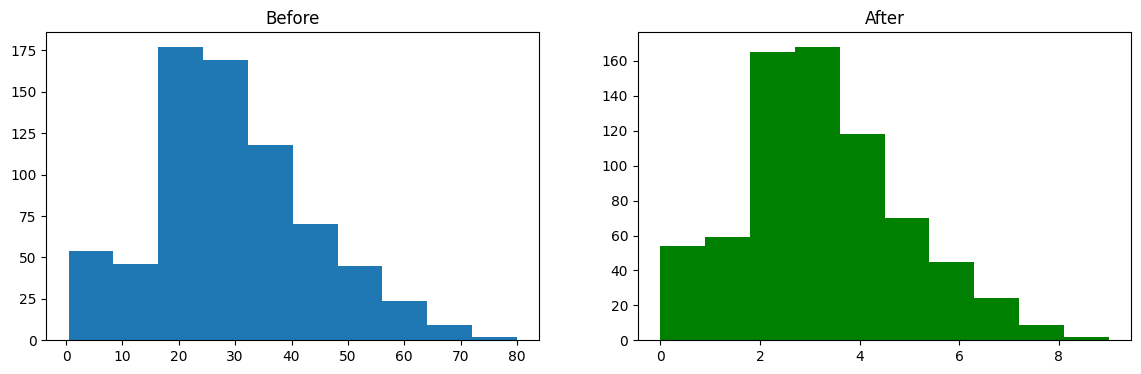

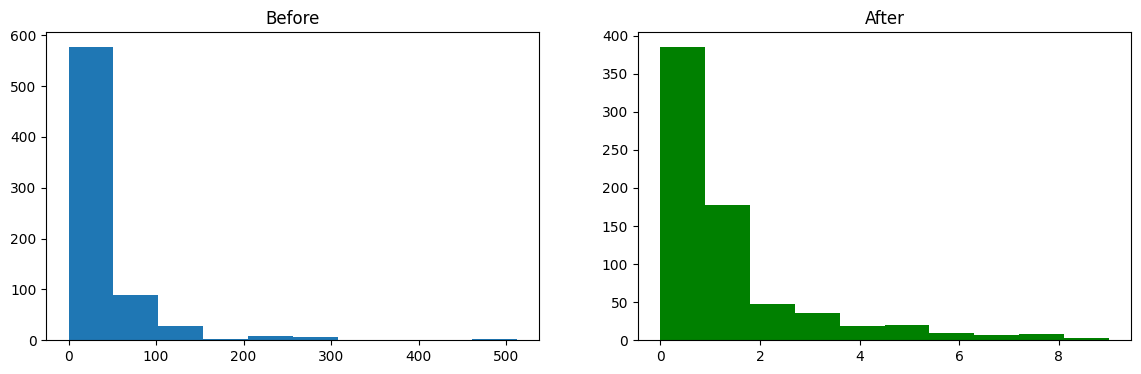

In [40]:
discretize(10, 'kmeans')

In [42]:
df2 = pd.read_csv("./src/kashti.csv",usecols=["age", "fare", "sibsp","parch", "survived"])


In [43]:
df2.head(5)

,survived,age,sibsp,parch,fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [44]:
df['family_size'] = df2['sibsp'] + df2['parch']
df.head()

,survived,age,fare,family_size
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [45]:
x = df.drop("survived", axis=1)
y = df["survived"]

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [47]:
x_train.head()

,age,fare,family_size
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [ ]:
# without binarization
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_test, y_pred)

0.6363636363636364

In [49]:
np.mean(cross_val_score(clf, x_train_trf, y_train, cv=5))

np.float64(0.6952707856598017)

In [53]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family_size'])
],remainder='passthrough')

In [54]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [56]:
pd.DataFrame(x_train_trf, columns=['family_size','age','fare'])

,family_size,age,fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [64]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf, y_train)
y_pred2 = clf.predict(x_test_trf)
accuracy_score(y_test, y_pred2)

0.6363636363636364

In [65]:
x_trf= trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6303599374021909)